# 📊 Telco Customer Churn Analysis

(Python + Machine Learning)

#📌 Project Overview

In this project, we perform Customer Churn Analysis using a combination of SQL for data preparation and Python for analysis and modeling.
The objective is to identify patterns that explain why customers leave a business and to build a predictive model that helps in early churn detection.

We start by preparing and transforming the raw transactional data using SQL, where we clean the dataset, engineer meaningful features, and create structured tables suitable for analysis.
Once the dataset is ready, we use Python to explore the data, visualize trends, and build a machine learning classification model to predict customer churn.

This end-to-end workflow demonstrates how SQL and Python can be combined effectively for real-world business analytics and decision-making.

#🧩 What Was Done in SQL

* Cleaned raw customer data by removing nulls and invalid records
* Created derived fields such as tenure, total charges, and customer behavior metrics
* Built structured tables for analysis and modeling
* Prepared a clean dataset ready for exploratory analysis and machine learning

# 🔍 What We Do in Python

* Load the cleaned dataset generated from SQL
* Perform Exploratory Data Analysis (EDA)
* Visualize customer churn patterns
* Encode categorical variables and scale features
* Train and evaluate a machine learning classification model
* Analyze performance using accuracy, confusion matrix, and other metrics

#Import Required Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#Upload Dataset
Upload the cleaned Telco CSV file exported from SQL.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving churn_analysis.csv to churn_analysis.csv


#Load Dataset
Read the uploaded CSV file into a pandas DataFrame.

In [ ]:
df = pd.read_csv("churn_analysis.csv")
df.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,churn_flag
0,7590-VHVEG,1,29.85,29.85,Month-to-month,Electronic check,0
1,5575-GNVDE,34,56.95,1889.50,One year,Mailed check,0
2,3668-QPYBK,2,53.85,108.15,Month-to-month,Mailed check,1
3,7795-CFOCW,45,42.30,1840.75,One year,Bank transfer (automatic),0
4,9237-HQITU,2,70.70,151.65,Month-to-month,Electronic check,1


#Basic Data Overview
Check structure, data types, and missing values.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      400 non-null    object 
 1   tenure          400 non-null    int64  
 2   MonthlyCharges  400 non-null    float64
 3   TotalCharges    400 non-null    float64
 4   Contract        400 non-null    object 
 5   PaymentMethod   400 non-null    object 
 6   churn_flag      400 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 22.0+ KB


,tenure,MonthlyCharges,TotalCharges,churn_flag
count,400.00000,400.000000,400.000000,400.000000
mean,31.48500,66.143375,2230.770375,0.255000
std,24.28568,29.400524,2175.436256,0.436407
min,1.00000,18.950000,19.150000,0.000000
25%,8.00000,44.350000,417.575000,0.000000
50%,28.00000,72.625000,1368.675000,0.000000
75%,52.00000,90.050000,3653.325000,1.000000
max,72.00000,115.100000,8129.300000,1.000000


#Data Cleaning
Convert TotalCharges to numeric and remove missing values.

In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

#Encode Categorical Variables
Convert categorical values into numerical format for modeling.

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#Exploratory Data Analysis (EDA)
Visualize churn distribution and spending behavior.

Churn Distribution

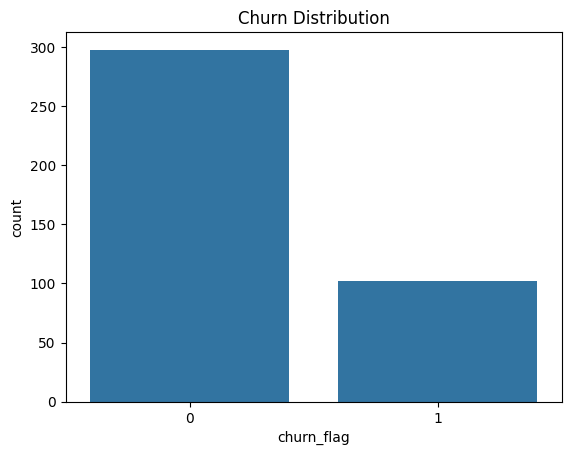

In [ ]:
sns.countplot(x='churn_flag', data=df)
plt.title('Churn Distribution')
plt.show()

Monthly Charges vs Churn

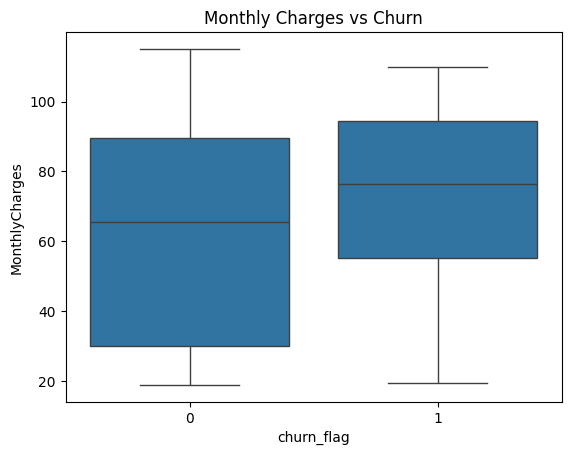

In [ ]:
sns.boxplot(x='churn_flag', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


#Feature Selection
Separate predictors and target variable.

In [ ]:
X = df.drop('churn_flag', axis=1)
y = df['churn_flag']

#Train-Test Split
Split data into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#Train Logistic Regression Model
Train a Logistic Regression model to predict churn.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#Model Evaluation
Check how well the model performs.

In [ ]:
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.92      0.86        71
           1       0.68      0.45      0.54        29

    accuracy                           0.78       100
   macro avg       0.74      0.68      0.70       100
weighted avg       0.77      0.78      0.76       100



#Confusion Matrix
Visualize model performance.

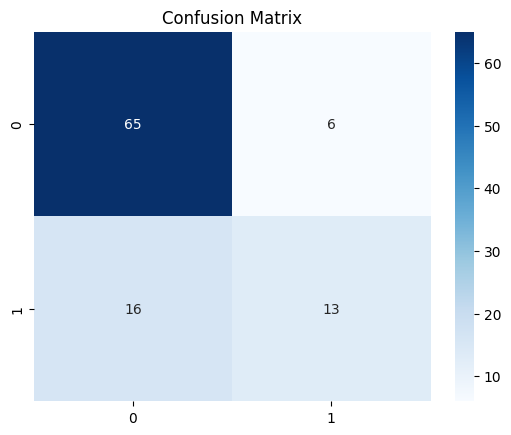

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Model Evaluation Summary

The confusion matrix shows how well the model predicts churn vs non-churn customers:

* True Positives: Correctly predicted churn customers
* True Negatives: Correctly predicted retained customers
* False Positives / Negatives: Areas for model improvement

This helps understand where the model performs well and where optimization is needed.

# 📊 Key Insights

* Customers with short tenure and month-to-month contracts are more likely to churn
* Higher monthly charges correlate with higher churn risk
* Long-term contract customers show significantly better retention
* Payment method and service combinations influence churn behavior

# 🚀 Next Steps (Power BI Phase)

* Build an interactive churn dashboard in Power BI
* Visualize:
  * Churn rate by contract type
  * Revenue at risk
  * Customer segmentation
* Add slicers for dynamic exploration
* Convert insights into business-driven retention strategies

# ✅ Conclusion

This project demonstrates a complete analytics workflow — from SQL-based data preparation to Python-driven modeling and insights.
It showcases practical skills in data cleaning, analysis, visualization, and business interpretation, making it a strong end-to-end data analytics project.